In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONSTANTS
# =========================
k      = 1.380649e-23
mmol   = 0.10415        # kg/mol
nmol   = 512
NA     = 6.02214076e23
massa  = mmol / NA   # kg (massa total del sistema)


def entropy_conf(fname, bins=70):
    """Entropia conformacional via histograma 2D (psi, phi)."""
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[6]))
                phi.append(float(cols[7]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges, edges], density=True)
    Ap = 360 / bins
    p  = hist * Ap * Ap
    S  = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)
    return S / massa


def entropy_ori(fname, bins=70):
    """Entropia orientacional via histograma 3D (theta, phi, psi)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
        np.linspace(-180, 180, bins),
    ]
    hist, _ = np.histogramdd((th, phi, psi), bins=intervals, density=True)
    Ath = 2 / bins
    A   = Ath * (360 / bins) * (360 / bins)
    p   = hist * A
    S   = -k * np.sum(p[p > 0] * np.log(p[p > 0]))
    return S / massa * nmol

P=    1 bar  300→305 K  Sc=150.52579143783976  So=163975.9072109133  St=164126.43300235114  J/(kg·K)
P= 1000 bar  310→315 K  Sc=149.23842410632506  So=158427.45212316758  St=158576.6905472739  J/(kg·K)
P= 2000 bar  320→325 K  Sc=144.83198995661837  So=145780.07370711793  St=145924.90569707454  J/(kg·K)
P= 3000 bar  325→330 K  Sc=129.75600647019303  So=121346.19999725954  St=121475.95600372973  J/(kg·K)
P= 4000 bar  330→335 K  Sc=133.83525235286675  So=133783.2691601367  St=133917.10441248957  J/(kg·K)
P= 5000 bar  335→340 K  Sc=45.516054391985904  So=56703.84906068782  St=56749.3651150798  J/(kg·K)


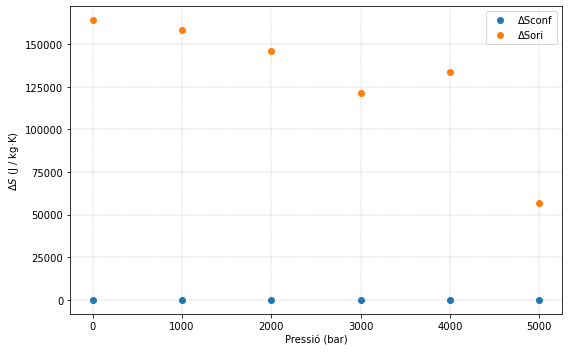

In [3]:
import os

base = "/Users/aressanuylatorre/Desktop/doc/NPG/fitxers"

# Parelles (T_baixa, T_alta, pressió)
parelles = [
    (300, 305,  1),
    (310, 315,  1000),
    (320, 325,  2000),
    (325, 330,  3000),
    (330, 335,  4000),
    (335, 340,  5000),
]

resultats = []

for T_a, T_b, P in parelles:
    fa = os.path.join(base, f"ang_ori_{T_a}_{P}_2.dat")
    fb = os.path.join(base, f"ang_ori_{T_b}_{P}_2.dat")

    Sc = -entropy_conf(fa) + entropy_conf(fb)
    So = -entropy_ori(fa)  + entropy_ori(fb)
    St = Sc + So

    resultats.append((P, T_a, T_b, Sc, So, St))
    print(f"P={P:5d} bar  {T_a}→{T_b} K  Sc={Sc}  So={So}  St={St}  J/(kg·K)")

# Plot
pressions = [r[0] for r in resultats]
Sc_list   = [r[3] for r in resultats]
So_list   = [r[4] for r in resultats]
St_list   = [r[5] for r in resultats]

plt.figure(figsize=(8,5))
plt.plot(pressions, Sc_list, 'o', label='ΔSconf')
plt.plot(pressions, So_list, 'o', label='ΔSori')
#plt.plot(pressions, St_list, 'o', label='ΔStotal')
plt.xlabel('Pressió (bar)')
plt.ylabel(r'$\Delta S$ (J / kg·K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

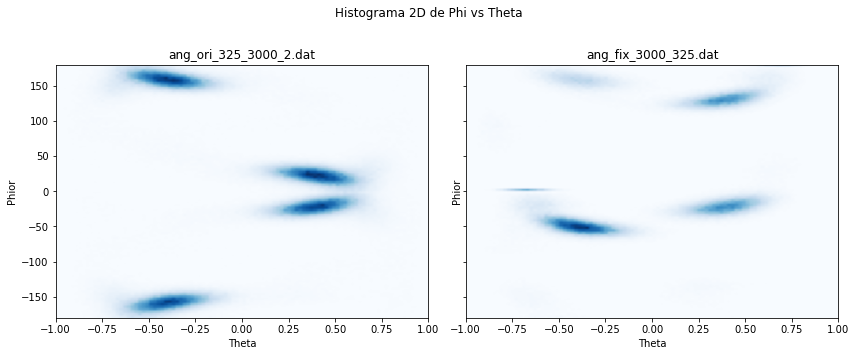

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def is_float(value):
    try:
        float(value)
        return True
    except ValueError:
        return False

def read_theta_phior(filename, header_lines=4, footer_lines=1,
                     theta_col=8, phior_col=10):
    theta = []
    phior = []
    with open(filename, "r") as f:
        lines = f.readlines()[header_lines:-footer_lines or None]

    for line in lines:
        sline = line.strip()
        if not sline or sline.startswith("*") or "Conf=" in sline:
            continue
        values = sline.split()
        if len(values) <= max(theta_col, phior_col):
            continue
        if not is_float(values[0]):
            continue
        try:
            theta_val = float(values[theta_col])
            phior_val = float(values[phior_col])
        except (ValueError, IndexError):
            continue
        theta.append(theta_val)
        phior.append(phior_val)

    return np.array(theta), np.array(phior)

def expand_paths(patterns):
    paths = []
    for pat in patterns:
        matches = sorted(glob.glob(pat))
        if matches:
            paths.extend(matches)
        elif os.path.exists(pat):
            paths.append(pat)
        else:
            print(f"⚠️ No s'ha trobat: {pat}")
    return paths

def compare_files_2d(file_list,
                     theta_bins=100, theta_range=(-1, 1),
                     phior_bins=100, phior_range=(-180, 180)):
    files = expand_paths(file_list)
    if not files:
        print("⚠️ Cap fitxer vàlid per comparar.")
        return

    n = len(files)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharex=True, sharey=True)
    if n == 1:
        axes = [axes]

    for ax, filename in zip(axes, files):
        theta, phior = read_theta_phior(filename)
        if len(theta) == 0 or len(phior) == 0:
            print(f"⚠️ No hi ha dades vàlides a {filename}")
            ax.set_title(os.path.basename(filename))
            continue

        h, xedges, yedges = np.histogram2d(theta, phior,
                                           bins=[theta_bins, phior_bins],
                                           range=[theta_range, phior_range],density=True)
        img = ax.imshow(h.T,
                        origin="lower",
                        aspect="auto",
                        extent=[theta_range[0], theta_range[1],
                                phior_range[0], phior_range[1]],
                        cmap="Blues")
        ax.set_title(os.path.basename(filename))
        ax.set_xlabel("Theta")
        ax.set_ylabel("Phior")

    #fig.colorbar(img, ax=axes, label="Counts")
    plt.suptitle("Histograma 2D de Phi vs Theta")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    #plt.savefig("/Users/aressanuylatorre/Desktop/doc/NPG/figures/comparativa_ori_des.png", dpi=150)
    plt.show()

# Exemple d'ús:
compare_files_2d([
    "/Users/aressanuylatorre/Desktop/doc/NPG/fitxers/ang_ori_325_3000_2.dat",
    "/Users/aressanuylatorre/Desktop/doc/NPG/antfiles/ang_fix_3000_325.dat"
])

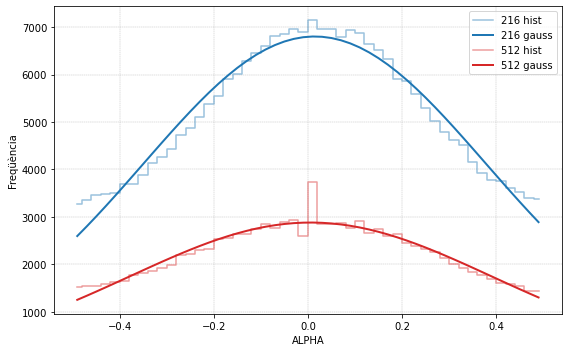

/Users/aressanuylatorre/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


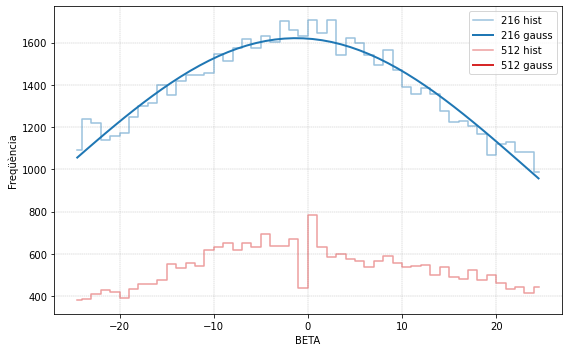

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma):
    return a * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

def read_theta_phior(filename):
    theta, phior = [], []
    with open(filename, "r") as f:
        lines = f.readlines()[4:-1]
    for line in lines:
        v = line.split()
        if len(v) >= 10:
            theta.append(float(v[8]))
            phior.append(float(v[9]))
    return np.array(theta), np.array(phior)

def fit_gaussian(data, bins=50, data_range=None):
    hist, edges = np.histogram(data, bins=bins, range=data_range,density=False)
    x = (edges[:-1] + edges[1:]) / 2
    p0 = [hist.max(), x[np.argmax(hist)], max(np.std(data), 1e-4)]
    try:
        popt, _ = curve_fit(gaussian, x, hist, p0=p0, maxfev=10000)
    except Exception:
        popt = p0
    return x, hist, popt

def compare_files(file_list,
                  theta_bins=50, theta_range=(-0.5,0.5),
                  phior_bins=50, phior_range=(-25,+25)):
    colors = ["tab:blue", "tab:red", "tab:green", "tab:orange", "tab:purple"]
    labels = ['216','512']
    
    # Theta overlay
    plt.figure(figsize=(8,5))
    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)
        x_t, h_t, p_t = fit_gaussian(theta, bins=theta_bins, data_range=theta_range)
        plt.plot(x_t, h_t, drawstyle="steps-mid", color=colors[i%len(colors)], alpha=0.45, label=f"{labels[i]} hist")
        plt.plot(x_t, gaussian(x_t, *p_t), '-', color=colors[i%len(colors)], linewidth=2, label=f"{labels[i]} gauss")
    plt.xlabel("ALPHA")
    plt.ylabel("Freqüència")
    #plt.title("Comparativa Theta + Ajust Gaussià")
    plt.legend()
    plt.grid(True, ls="--", lw=0.4)
    plt.tight_layout()
    plt.savefig("/Users/aressanuylatorre/Desktop/doc/NPG/figures/comparativa_ori_des_2_a_nodens.png", dpi=150)
    plt.show()
    
    # Phior overlay
    plt.figure(figsize=(8,5))
    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)
        x_p, h_p, p_p = fit_gaussian(phior, bins=phior_bins, data_range=phior_range)
        plt.plot(x_p, h_p, drawstyle="steps-mid", color=colors[i%len(colors)], alpha=0.45, label=f"{labels[i]} hist")
        plt.plot(x_p, gaussian(x_p, *p_p), '-', color=colors[i%len(colors)], linewidth=2, label=f"{labels[i]} gauss")
    plt.xlabel("BETA")
    plt.ylabel("Freqüència")
    #plt.title("Comparativa Phior + Ajust Gaussià")
    plt.legend()
    plt.grid(True, ls="--", lw=0.4)
    plt.tight_layout()
    plt.savefig("/Users/aressanuylatorre/Desktop/doc/NPG/figures/comparativa_ori_des_2_b_nodens.png", dpi=150)
    plt.show()

# Exemple d'ús
compare_files([
    "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_305_1_2.dat",
    "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
])

In [ ]:
ang_ori  = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
ang_conf = ang_ori

Sconf2 = entropy_conf(ang_conf)
Sori2  = entropy_ori(ang_ori)

#print(f" S_conf={Sconf2:.4e}  S_ori={Sori2:.4e}  J/(kg K)")


ang_ori  = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_300_1_2.dat"
ang_conf = ang_ori

Sconf3 = entropy_conf(ang_conf)
Sori3  = entropy_ori(ang_ori)

print(f" S_conf={Sconf3:.4e}  S_ori={Sori3:.4e}  J/(kg K)")

ang_ori  = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_300.dat"
ang_conf = ang_ori

Sconf4 = entropy_conf(ang_conf)
Sori4  = entropy_ori(ang_ori)

#print(f" S_conf={Sconf4:.4e}  S_ori={Sori4:.4e}  J/(kg K)")

Sc216 = Sconf2 - Sconf4
So216 = Sori2 - Sori4

Sc512 = Sconf1 - Sconf3
So512 = Sori1 - Sori3

print(f" 216|Sc={Sc216}  So={So216}  J/(kg K)")
print(f" 512|Sc={Sc512}  So={So512}  J/(kg K)")

 S_conf=7.7858e+02  S_ori=9.3243e+02  J/(kg K)
 S_conf=6.2778e+02  S_ori=6.1386e+02  J/(kg K)
 216|Sc=144.86634563676682  So=245.19556626628332  J/(kg K)
 512|Sc=150.80168651285123  So=318.5696916363303  J/(kg K)


In [1]:
import numpy as np

def entropy_conf(fname, bins):
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[6]))
                phi.append(float(cols[7]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges, edges], density=True)
    Ap = 360.0 / bins
    p = hist * Ap * Ap
    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)
    return S / massa * nmol

def compare_entropy_by_bins(bins_list,
                            file_216_a,
                            file_216_b,
                            file_512_a,
                            file_512_b):
    Sc216 = []
    Sc512 = []
    for b in bins_list:
        S216_a = entropy_conf(file_216_a, bins=b)
        S216_b = entropy_conf(file_216_b, bins=b)
        Sc216.append(S216_a - S216_b)

        S512_a = entropy_conf(file_512_a, bins=b)
        S512_b = entropy_conf(file_512_b, bins=b)
        Sc512.append(S512_a - S512_b)

    return np.array(Sc216), np.array(Sc512)

bins_list = np.arange(20, 421, 20)

file_216_a = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
file_216_b = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_300.dat"
file_512_a = "/Users/aressanuylatorre/Desktop/doc/NPG/fitxers/ang_ori_305_1_2.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/NPG/fitxers/ang_ori_300_1_2.dat"

Sc216, Sc512 = compare_entropy_by_bins(bins_list,
                                       file_216_a,
                                       file_216_b,
                                       file_512_a,
                                       file_512_b)



import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(bins_list, Sc216, '-o', label='216')
plt.plot(bins_list, Sc512, '-o', label='512')
plt.xlabel('bins')
plt.ylabel(r'$\Delta Sconf$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat'

bins= 20  So216=2.351126e+02  So512=2.828228e+02
bins= 40  So216=2.643438e+02  So512=3.235513e+02
bins= 60  So216=2.554678e+02  So512=3.248753e+02
bins= 80  So216=2.325726e+02  So512=3.092188e+02
bins=100  So216=2.060006e+02  So512=2.850637e+02
bins=120  So216=1.798946e+02  So512=2.585428e+02
bins=140  So216=1.559252e+02  So512=2.329277e+02
bins=160  So216=1.347732e+02  So512=2.087474e+02
bins=180  So216=1.162675e+02  So512=1.869701e+02
bins=200  So216=1.001488e+02  So512=1.672988e+02
bins=220  So216=8.645401e+01  So512=1.496760e+02
bins=240  So216=7.453979e+01  So512=1.339067e+02
bins=260  So216=6.439271e+01  So512=1.197857e+02
bins=280  So216=5.558875e+01  So512=1.072332e+02
bins=300  So216=4.807345e+01  So512=9.600789e+01
bins=320  So216=4.185110e+01  So512=8.601102e+01
bins=340  So216=3.634846e+01  So512=7.707006e+01
bins=360  So216=3.193746e+01  So512=6.908873e+01
bins=380  So216=2.797711e+01  So512=6.204116e+01
bins=400  So216=2.453586e+01  So512=5.574652e+01
bins=420  So216=2.16

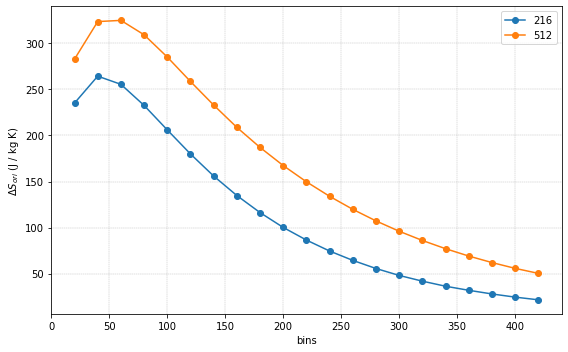

In [ ]:
def compare_entropy_ori_by_bins(bins_list,
                                file_216_a,
                                file_216_b,
                                file_512_a,
                                file_512_b):
    So216 = []
    So512 = []
    for b in bins_list:
        S216_a = entropy_ori(file_216_a, bins=b)
        S216_b = entropy_ori(file_216_b, bins=b)
        So216.append(S216_a - S216_b)

        S512_a = entropy_ori(file_512_a, bins=b)
        S512_b = entropy_ori(file_512_b, bins=b)
        So512.append(S512_a - S512_b)

    return np.array(So216), np.array(So512)

bins_list = np.arange(20, 421, 20) 

file_216_a = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
file_216_b = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_300.dat"
file_512_a = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_305_1_2.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_300_1_2.dat"

So216, So512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216, s512 in zip(bins_list, So216, So512):
    print(f"bins={b:3d}  So216={s216:.6e}  So512={s512:.6e}")

plt.figure(figsize=(8,5))
plt.plot(bins_list, So216, '-o', label='216')
plt.plot(bins_list, So512, '-o', label='512')
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

bins= 20  So216=2.7422e+02 ± 2.8657e-01  So512=3.2987e+02 ± 1.4961e-01
bins= 40  So216=2.8520e+02 ± 2.9018e-01  So512=3.4908e+02 ± 1.5611e-01
bins= 60  So216=2.6868e+02 ± 2.7487e-01  So512=3.4168e+02 ± 1.5533e-01
bins= 80  So216=2.4152e+02 ± 2.5452e-01  So512=3.2111e+02 ± 1.4906e-01
bins=100  So216=2.1231e+02 ± 2.3468e-01  So512=2.9379e+02 ± 1.4150e-01
bins=120  So216=1.8447e+02 ± 2.1609e-01  So512=2.6512e+02 ± 1.3434e-01
bins=140  So216=1.5931e+02 ± 1.9981e-01  So512=2.3799e+02 ± 1.2789e-01
bins=160  So216=1.3733e+02 ± 1.8479e-01  So512=2.1271e+02 ± 1.2213e-01
bins=180  So216=1.1823e+02 ± 1.7102e-01  So512=1.9012e+02 ± 1.1662e-01
bins=200  So216=1.0167e+02 ± 1.5900e-01  So512=1.6983e+02 ± 1.1131e-01
bins=220  So216=8.7644e+01 ± 1.4753e-01  So512=1.5174e+02 ± 1.0634e-01
bins=240  So216=7.5479e+01 ± 1.3728e-01  So512=1.3559e+02 ± 1.0157e-01
bins=260  So216=6.5141e+01 ± 1.2789e-01  So512=1.2118e+02 ± 9.7100e-02
bins=280  So216=5.6189e+01 ± 1.1938e-01  So512=1.0839e+02 ± 9.2588e-02
bins=3

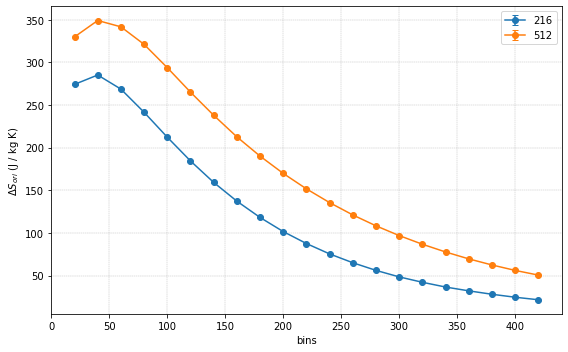

In [ ]:
def entropy_ori_with_error(fname, bins=70):
    """Entropia orientacional + error estadístic."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
        np.linspace(-180, 180, bins),
    ]

    # Usem density=False per tenir counts bruts → necessari per l'error
    counts, _ = np.histogramdd((th, phi, psi), bins=intervals, density=False)
    N = counts.sum()

    Ath = 2 / bins
    A   = Ath * (360 / bins) * (360 / bins)
    p   = counts / N  # probabilitat per bin (sense density)

    mask = p > 0

    # Entropia (equivalent a l'original)
    S = -k * np.sum(p[mask] * np.log(p[mask] / A))  # corregim pel volum del bin

    # Error estadístic de Shannon
    log_p = np.log(p[mask] / A)
    E1 = np.sum(p[mask] * log_p**2)
    E2 = (np.sum(p[mask] * log_p))**2
    sigma_S = k * np.sqrt((E1 - E2) / N)

    S_scaled   = S / massa * nmol
    err_scaled = sigma_S / massa * nmol

    return S_scaled, err_scaled


def compare_entropy_ori_by_bins(bins_list,
                                file_216_a, file_216_b,
                                file_512_a, file_512_b):
    So216, So512 = [], []
    Err216, Err512 = [], []

    for b in bins_list:
        S216_a, e216_a = entropy_ori_with_error(file_216_a, bins=b)
        S216_b, e216_b = entropy_ori_with_error(file_216_b, bins=b)
        So216.append(S216_a - S216_b)
        Err216.append(np.sqrt(e216_a**2 + e216_b**2))

        S512_a, e512_a = entropy_ori_with_error(file_512_a, bins=b)
        S512_b, e512_b = entropy_ori_with_error(file_512_b, bins=b)
        So512.append(S512_a - S512_b)
        Err512.append(np.sqrt(e512_a**2 + e512_b**2))

    return (np.array(So216), np.array(Err216),
            np.array(So512), np.array(Err512))


# ── execució ──────────────────────────────────────────────────────────────────
bins_list = np.arange(20, 421, 20)
file_216_a = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
file_216_b = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_300.dat"
file_512_a = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_305_1_2.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_300_1_2.dat"

So216, Err216, So512, Err512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216, e216, s512, e512 in zip(bins_list, So216, Err216, So512, Err512):
    print(f"bins={b:3d}  So216={s216:.4e} ± {e216:.4e}  So512={s512:.4e} ± {e512:.4e}")

# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.errorbar(bins_list, So216, yerr=Err216, fmt='-o', label='216', capsize=3)
plt.errorbar(bins_list, So512, yerr=Err512, fmt='-o', label='512', capsize=3)
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
def entropy_ori(fname, bins=70):
    """Entropia orientacional via histograma 3D (theta, phi, psi)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
        np.linspace(-180, 180, bins),
    ]
    hist, _ = np.histogramdd((th, phi, psi), bins=intervals, density=True)
    Ath = 2 / bins
    A   = Ath * (360 / bins) * (360 / bins)
    p   = hist * A
    S   = -k * np.sum(p[p > 0] * np.log(p[p > 0]))
    return S / massa * nmolplt.show()

bins= 20  So216=1.221249e+02  So512=1.445402e+02
bins= 40  So216=1.377706e+02  So512=1.619376e+02
bins= 60  So216=1.407919e+02  So512=1.668174e+02
bins= 80  So216=1.412113e+02  So512=1.689071e+02
bins=100  So216=1.408700e+02  So512=1.699262e+02
bins=120  So216=1.400714e+02  So512=1.704748e+02
bins=140  So216=1.390447e+02  So512=1.707275e+02
bins=160  So216=1.378967e+02  So512=1.707519e+02
bins=180  So216=1.364493e+02  So512=1.706762e+02
bins=200  So216=1.350154e+02  So512=1.704821e+02
bins=220  So216=1.334993e+02  So512=1.701647e+02
bins=240  So216=1.319551e+02  So512=1.697295e+02
bins=260  So216=1.304342e+02  So512=1.692333e+02
bins=280  So216=1.287869e+02  So512=1.686762e+02
bins=300  So216=1.270149e+02  So512=1.679734e+02
bins=320  So216=1.250367e+02  So512=1.671701e+02
bins=340  So216=1.231249e+02  So512=1.663617e+02
bins=360  So216=1.208472e+02  So512=1.654031e+02
bins=380  So216=1.189192e+02  So512=1.643891e+02
bins=400  So216=1.162894e+02  So512=1.633065e+02
bins=420  So216=1.14

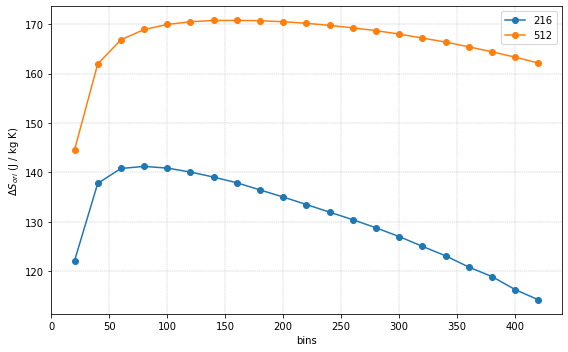

In [ ]:
def entropy_ori2(fname, bins=70):
    """Entropia orientacional via histograma 3D (theta, phi, psi)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
    ]
    hist, _ = np.histogramdd((th, psi), bins=intervals, density=True)
    Ath = 2 / bins
    A   = Ath * (360 / bins)
    p   = hist * A
    S   = -k * np.sum(p[p > 0] * np.log(p[p > 0]))
    return S / massa * nmol



def compare_entropy_ori_by_bins(bins_list,
                                file_216_a,
                                file_216_b,
                                file_512_a,
                                file_512_b):
    So216 = []
    So512 = []
    for b in bins_list:
        S216_a = entropy_ori2(file_216_a, bins=b)
        S216_b = entropy_ori2(file_216_b, bins=b)
        So216.append(S216_a - S216_b)

        S512_a = entropy_ori2(file_512_a, bins=b)
        S512_b = entropy_ori2(file_512_b, bins=b)
        So512.append(S512_a - S512_b)

    return np.array(So216), np.array(So512)

bins_list = np.arange(20, 421, 20)

file_216_a = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
file_216_b = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_300.dat"
file_512_a = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_305_1_2.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_300_1_2.dat"

So216, So512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216, s512 in zip(bins_list, So216, So512):
    print(f"bins={b:3d}  So216={s216:.6e}  So512={s512:.6e}")

plt.figure(figsize=(8,5))
plt.plot(bins_list, So216, '-o', label='216')
plt.plot(bins_list, So512, '-o', label='512')
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

bins= 20  So216=1.342561e+02  So512=1.460247e+02
bins= 40  So216=1.534713e+02  So512=1.663284e+02
bins= 60  So216=1.585280e+02  So512=1.717647e+02
bins= 80  So216=1.605613e+02  So512=1.741261e+02
bins=100  So216=1.616093e+02  So512=1.752768e+02
bins=120  So216=1.618922e+02  So512=1.759194e+02
bins=140  So216=1.619238e+02  So512=1.762445e+02
bins=160  So216=1.616019e+02  So512=1.763187e+02
bins=180  So216=1.609574e+02  So512=1.762567e+02
bins=200  So216=1.601999e+02  So512=1.760826e+02
bins=220  So216=1.590645e+02  So512=1.758418e+02
bins=240  So216=1.579319e+02  So512=1.754481e+02
bins=260  So216=1.566357e+02  So512=1.749720e+02
bins=280  So216=1.551742e+02  So512=1.743840e+02
bins=300  So216=1.532488e+02  So512=1.738012e+02
bins=320  So216=1.514032e+02  So512=1.729998e+02
bins=340  So216=1.491597e+02  So512=1.721453e+02
bins=360  So216=1.469903e+02  So512=1.712324e+02
bins=380  So216=1.446687e+02  So512=1.702826e+02
bins=400  So216=1.418129e+02  So512=1.691806e+02
bins=420  So216=1.39

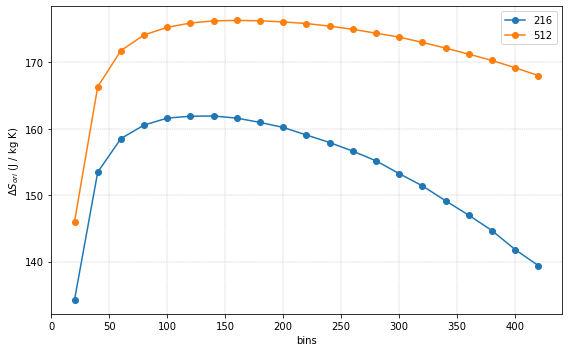

In [ ]:
def entropy_ori2(fname, bins=70):
    """Entropia orientacional via histograma 3D (theta, phi, psi)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                psi.append(float(cols[9]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
    ]
    hist, _ = np.histogramdd((th, psi), bins=intervals, density=True)
    Ath = 2 / bins
    A   = Ath * (360 / bins)
    p   = hist * A
    S   = -k * np.sum(p[p > 0] * np.log(p[p > 0]))
    return S / massa * nmol



def compare_entropy_ori_by_bins(bins_list,
                                file_216_a,
                                file_216_b,
                                file_512_a,
                                file_512_b):
    So216 = []
    So512 = []
    for b in bins_list:
        S216_a = entropy_ori2(file_216_a, bins=b)
        S216_b = entropy_ori2(file_216_b, bins=b)
        So216.append(S216_a - S216_b)

        S512_a = entropy_ori2(file_512_a, bins=b)
        S512_b = entropy_ori2(file_512_b, bins=b)
        So512.append(S512_a - S512_b)

    return np.array(So216), np.array(So512)

bins_list = np.arange(20, 421, 20)

file_216_a = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
file_216_b = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_300.dat"
file_512_a = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_305_1_2.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_300_1_2.dat"

So216, So512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216, s512 in zip(bins_list, So216, So512):
    print(f"bins={b:3d}  So216={s216:.6e}  So512={s512:.6e}")

plt.figure(figsize=(8,5))
plt.plot(bins_list, So216, '-o', label='216')
plt.plot(bins_list, So512, '-o', label='512')
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

bins= 20  S216_a=5.767383e+02  S216_b=3.416257e+02  S512_a=6.043906e+02  S512_b=3.215678e+02  ΔS216=2.351126e+02  ΔS512=2.828228e+02
bins= 30  S216_a=6.877176e+02  S216_b=4.295647e+02  S512_a=7.213121e+02  S512_b=4.094345e+02  ΔS216=2.581529e+02  ΔS512=3.118775e+02
bins= 40  S216_a=7.610103e+02  S216_b=4.966665e+02  S512_a=8.006265e+02  S512_b=4.770752e+02  ΔS216=2.643438e+02  ΔS512=3.235513e+02
bins= 50  S216_a=8.126549e+02  S216_b=5.502155e+02  S512_a=8.581295e+02  S512_b=5.311231e+02  ΔS216=2.624394e+02  ΔS512=3.270064e+02
bins= 60  S216_a=8.496940e+02  S216_b=5.942262e+02  S512_a=9.007690e+02  S512_b=5.758937e+02  ΔS216=2.554678e+02  ΔS512=3.248753e+02
bins= 70  S216_a=8.765409e+02  S216_b=6.313454e+02  S512_a=9.324251e+02  S512_b=6.138554e+02  ΔS216=2.451956e+02  ΔS512=3.185697e+02
bins= 80  S216_a=8.957586e+02  S216_b=6.631860e+02  S512_a=9.559550e+02  S512_b=6.467362e+02  ΔS216=2.325726e+02  ΔS512=3.092188e+02
bins= 90  S216_a=9.104601e+02  S216_b=6.909900e+02  S512_a=9.733771e+

/var/folders/jc/b_kdsy9x0wj1yp14tq6btzg80000gn/T/ipykernel_7780/2814615354.py:57: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(bins_list, So216, '-o', label='216 ΔS', linestyle='--')
/var/folders/jc/b_kdsy9x0wj1yp14tq6btzg80000gn/T/ipykernel_7780/2814615354.py:58: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(bins_list, So512, '-o', label='512 ΔS', linestyle='--')


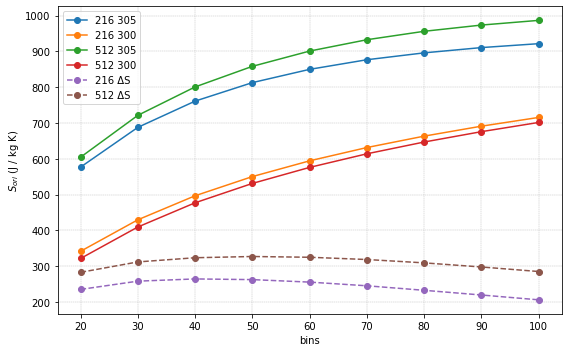

In [ ]:
def compare_entropy_ori_by_bins(bins_list,
                                file_216_a,
                                file_216_b,
                                file_512_a,
                                file_512_b):
    S216_a_list = []
    S216_b_list = []
    S512_a_list = []
    S512_b_list = []
    So216 = []
    So512 = []

    for b in bins_list:
        S216_a = entropy_ori(file_216_a, bins=b)
        S216_b = entropy_ori(file_216_b, bins=b)
        S512_a = entropy_ori(file_512_a, bins=b)
        S512_b = entropy_ori(file_512_b, bins=b)

        S216_a_list.append(S216_a)
        S216_b_list.append(S216_b)
        S512_a_list.append(S512_a)
        S512_b_list.append(S512_b)

        So216.append(S216_a - S216_b)
        So512.append(S512_a - S512_b)

    return (np.array(S216_a_list), np.array(S216_b_list),
            np.array(S512_a_list), np.array(S512_b_list),
            np.array(So216), np.array(So512))


bins_list = np.arange(20, 101, 10)

file_216_a = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_305.dat"
file_216_b = "/Users/aressanuylatorre/Desktop/doc/NPG/ang_fix_NPG_300.dat"
file_512_a = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_305_1_2.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/newNPG/files/ang_ori_300_1_2.dat"

S216_a, S216_b, S512_a, S512_b, So216, So512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216a, s216b, s512a, s512b, s216, s512 in zip(
        bins_list, S216_a, S216_b, S512_a, S512_b, So216, So512):
    print(f"bins={b:3d}  S216_a={s216a:.6e}  S216_b={s216b:.6e}  "
          f"S512_a={s512a:.6e}  S512_b={s512b:.6e}  "
          f"ΔS216={s216:.6e}  ΔS512={s512:.6e}")

plt.figure(figsize=(8, 5))
#ori=65 / 
plt.plot(bins_list, S216_a, '-o', label='216 305')
plt.plot(bins_list, S216_b, '-o', label='216 300')
plt.plot(bins_list, S512_a, '-o', label='512 305')
plt.plot(bins_list, S512_b, '-o', label='512 300')
plt.plot(bins_list, So216, '-o', label='216 ΔS', linestyle='--')
plt.plot(bins_list, So512, '-o', label='512 ΔS', linestyle='--')
plt.xlabel('bins')
plt.ylabel(r'$S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

bins= 20  S216_a=5.761983e+02  S216_b=3.326210e+02  S512_a=6.023885e+02  S512_b=3.507171e+02  ΔS216=2.435772e+02  ΔS512=2.516714e+02
bins= 30  S216_a=6.862954e+02  S216_b=4.197329e+02  S512_a=7.188119e+02  S512_b=4.405530e+02  ΔS216=2.665625e+02  ΔS512=2.782589e+02
bins= 40  S216_a=7.591544e+02  S216_b=4.867118e+02  S512_a=7.977873e+02  S512_b=5.087297e+02  ΔS216=2.724426e+02  ΔS512=2.890576e+02
bins= 50  S216_a=8.103448e+02  S216_b=5.402040e+02  S512_a=8.551373e+02  S512_b=5.626946e+02  ΔS216=2.701408e+02  ΔS512=2.924428e+02
bins= 60  S216_a=8.471039e+02  S216_b=5.842926e+02  S512_a=8.978368e+02  S512_b=6.072335e+02  ΔS216=2.628113e+02  ΔS512=2.906033e+02
bins= 70  S216_a=8.736830e+02  S216_b=6.216559e+02  S512_a=9.295731e+02  S512_b=6.448464e+02  ΔS216=2.520271e+02  ΔS512=2.847267e+02
bins= 80  S216_a=8.932421e+02  S216_b=6.537529e+02  S512_a=9.532808e+02  S512_b=6.773047e+02  ΔS216=2.394892e+02  ΔS512=2.759761e+02
bins= 90  S216_a=9.080198e+02  S216_b=6.819415e+02  S512_a=9.711537e+

/var/folders/jc/b_kdsy9x0wj1yp14tq6btzg80000gn/T/ipykernel_7780/394311396.py:57: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(bins_list, So216, '-o', label='216 ΔS', linestyle='--')
/var/folders/jc/b_kdsy9x0wj1yp14tq6btzg80000gn/T/ipykernel_7780/394311396.py:58: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(bins_list, So512, '-o', label='512 ΔS', linestyle='--')


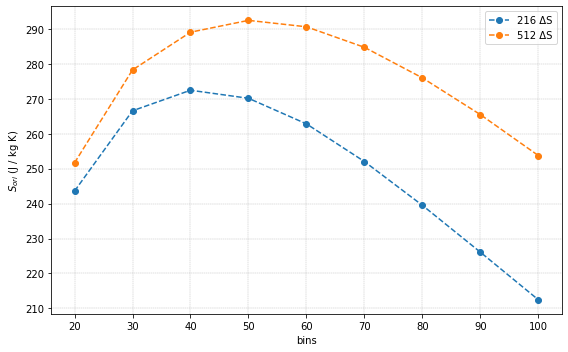

In [ ]:
def compare_entropy_ori_by_bins(bins_list,
                                file_216_a,
                                file_216_b,
                                file_512_a,
                                file_512_b):
    S216_a_list = []
    S216_b_list = []
    S512_a_list = []
    S512_b_list = []
    So216 = []
    So512 = []

    for b in bins_list:
        S216_a = entropy_ori(file_216_a, bins=b)
        S216_b = entropy_ori(file_216_b, bins=b)
        S512_a = entropy_ori(file_512_a, bins=b)
        S512_b = entropy_ori(file_512_b, bins=b)

        S216_a_list.append(S216_a)
        S216_b_list.append(S216_b)
        S512_a_list.append(S512_a)
        S512_b_list.append(S512_b)

        So216.append(S216_a - S216_b)
        So512.append(S512_a - S512_b)

    return (np.array(S216_a_list), np.array(S216_b_list),
            np.array(S512_a_list), np.array(S512_b_list),
            np.array(So216), np.array(So512))


bins_list = np.arange(20, 101, 10)

file_216_a = "/Users/aressanuylatorre/Desktop/doc/NPG/antfiles/ang_fix_2000_325.dat"
file_216_b = "/Users/aressanuylatorre/Desktop/doc/NPG/antfiles/ang_fix_2000_320.dat"
file_512_a = "/Users/aressanuylatorre/Desktop/doc/NPG/fitxers/ang_ori_325_2000_2.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/NPG/fitxers/ang_ori_320_2000_2.dat"

S216_a, S216_b, S512_a, S512_b, So216, So512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216a, s216b, s512a, s512b, s216, s512 in zip(
        bins_list, S216_a, S216_b, S512_a, S512_b, So216, So512):
    print(f"bins={b:3d}  S216_a={s216a:.6e}  S216_b={s216b:.6e}  "
          f"S512_a={s512a:.6e}  S512_b={s512b:.6e}  "
          f"ΔS216={s216:.6e}  ΔS512={s512:.6e}")

plt.figure(figsize=(8, 5))
#ori=65 / 
#plt.plot(bins_list, S216_a, '-o', label='216 305')
#plt.plot(bins_list, S216_b, '-o', label='216 300')
#plt.plot(bins_list, S512_a, '-o', label='512 305')
#plt.plot(bins_list, S512_b, '-o', label='512 300')
plt.plot(bins_list, So216, '-o', label='216 ΔS', linestyle='--')
plt.plot(bins_list, So512, '-o', label='512 ΔS', linestyle='--')
plt.xlabel('bins')
plt.ylabel(r'$S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()